# Démo de Régression Linéaire -- pour le Cours Magistral #1

Attention, ce notebook contient des erreurs méthodologiques (pas de train/test split par exemple), c'est une première démo très primaire juste pour montrer qq outils très simples

In [1]:
import numpy as np
import pandas as pd
import sklearn
import sklearn.model_selection
import sklearn.linear_model
import sklearn.preprocessing

In [2]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.ion()

### Remarque: les parties sont indépendantes

# Chargement des données, vocabulaire

Puisqu'on n'a jamais fait de régression linéaire en TD, et qu'on en a parlé, mais assez rapidement, en cours, on commence par une illustration de ce que peut faire la régression linéaire, sur un cas concret:

C'est le fameux *boston house market* data set: 

https://archive.ics.uci.edu/ml/machine-learning-databases/housing/

Mis sur Kaggle plus récemment:
https://www.kaggle.com/vikrishnan/boston-house-prices/ 

On s'inspire assez amplement de la solution de l'autrice (Kaggle) du dataset, au moins pour ce qui est du chargement des données:
https://www.kaggle.com/vikrishnan/house-sales-price-using-regression

En gros, on a des données sur différents quartiers de Boston, et pour chaque quartier, on a le prix médian des maisons (ou appartements). On cherche à comprendre comment certains facteurs du voisinage déterminent le prix des maisons d'un quartier. Ou bien plus simplement, dans le cadre de ce DM, on se contente de tenter de prédire le prix des maisons en fonction des données fournies en entrée.

Comme d'habitude, on a $N$ points dans l'ensemble d'entraînement, chaque point de donnée est en dimension $D$, et les labels à prédire sont des valeurs continues, $y_n\in \mathbb{R}$.

Les attributs sont décrits ainsi à l'origine:

7. Attribute Information:

    1. CRIM      per capita crime rate by town
    2. ZN        proportion of residential land zoned for lots over 25,000 sq.ft.
    3. INDUS     proportion of non-retail business acres per town
    4. CHAS      Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
    5. NOX       nitric oxides concentration (parts per 10 million)
    6. RM        average number of rooms per dwelling
    7. AGE       proportion of owner-occupied units built prior to 1940
    8. DIS       weighted distances to five Boston employment centres
    9. RAD       index of accessibility to radial highways
    10. TAX      full-value property-tax rate per USD10,000
    11. PTRATIO  pupil-teacher ratio by town
    12. B        $1000(Bk - 0.63)^2$ where $Bk$ is the proportion of blacks by town
    13. LSTAT    percentage lower status of the population
    14. MEDV     Median value of owner-occupied homes in 1000 USD
    

## Partie 1.0 - petite démo de statistiques descriptives

Ici, vous n'avez rien à faire, juste à lire ce qu'on vous présente (ce sera bien pratique pour les projets!)

In [3]:
# chargement des données
filename = "TP-RegressionLineaire-data-partie1-housing.csv"
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
dataset = pd.read_csv(filename, delim_whitespace=True, names=names)
dataset.head(4)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4


# Vocabulaire

citer le nom de deux features.
- ZN et INDUS par exemple.

quel est le nombre de points de données?
- N=506

quelle est la dimension des données ? Quel est le nombre de features ?
- D =13 car 14-1

Quel va etre le type de tache ? (supervisé ou non ? Classification ou Regression ou ... ?)


In [4]:
dataset

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [5]:
x_d = dataset['RM'].values  ## feature ou colonne numero d, ici indiquee par le label "RM"
m_d= np.mean(x_d) #moyenne
s_d = np.std(x_d) # ecart type


In [6]:
m_d, s_d

(6.284634387351779, 0.7019225143345689)

In [7]:
x_standardized_d = (x_d-m_d)/s_d

m_d= np.mean(x_standardized_d)
s_d = np.std(x_standardized_d)

m_d, s_d

(-1.0882818581305882e-16, 0.9999999999999999)

In [8]:
dataset.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [9]:
a=np.random.random((6,3))
a, a[:-1], a[-1], a[a.shape[0]-1]

(array([[0.78722662, 0.6181762 , 0.6433165 ],
        [0.2313678 , 0.63185589, 0.47157861],
        [0.68092683, 0.94960328, 0.89271159],
        [0.97997793, 0.18253249, 0.84263932],
        [0.66020272, 0.24152109, 0.56659219],
        [0.4401404 , 0.38594182, 0.96309556]]),
 array([[0.78722662, 0.6181762 , 0.6433165 ],
        [0.2313678 , 0.63185589, 0.47157861],
        [0.68092683, 0.94960328, 0.89271159],
        [0.97997793, 0.18253249, 0.84263932],
        [0.66020272, 0.24152109, 0.56659219]]),
 array([0.4401404 , 0.38594182, 0.96309556]),
 array([0.4401404 , 0.38594182, 0.96309556]))

In [10]:
## les colonnes (sauf la dernière) correspondent aux variables explicatives du prix (features)
features = dataset.columns[:-1]
## mon "X"

# la derniere colonne, MEDV, correspond à la valeur médiane (Median Value) des maisons dans un quartier
label = dataset.columns[-1]
## mon "Y"

In [11]:
features, label

(Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
        'PTRATIO', 'B', 'LSTAT'],
       dtype='object'),
 'MEDV')

In [12]:
print(dataset.shape)

(506, 14)


In [13]:
## on convertit les tableaux pandas en tabeaux numpy
X = dataset[features].values
Y = dataset[label].values

In [14]:
X

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
        4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
        9.1400e+00],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
        4.0300e+00],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        5.6400e+00],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
        6.4800e+00],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        7.8800e+00]])

In [15]:
X.shape, Y.shape

((506, 13), (506,))

In [16]:
X[503]

array([6.0760e-02, 0.0000e+00, 1.1930e+01, 0.0000e+00, 5.7300e-01,
       6.9760e+00, 9.1000e+01, 2.1675e+00, 1.0000e+00, 2.7300e+02,
       2.1000e+01, 3.9690e+02, 5.6400e+00])

## Fit par regression lineaire (brutale)

Ici on n'est pas très fin, mais bon, c'est pour avoir un exemple concret:

In [17]:
monModele = sklearn.linear_model.LinearRegression()


In [18]:
monModele.coef_  # les valeurs du vecteur a dans ma fonction ax+b

AttributeError: 'LinearRegression' object has no attribute 'coef_'

In [19]:
monModele.fit(X, Y) ## attention, ne faites pas ça chez vous ! C'est tres dangereux d'entrainer sur toutes les données ! On le fait ici juste car c'est le premier cours !


LinearRegression()

In [20]:
monModele.coef_, monModele.intercept_  # vec(a), b 

(array([-1.08011358e-01,  4.64204584e-02,  2.05586264e-02,  2.68673382e+00,
        -1.77666112e+01,  3.80986521e+00,  6.92224640e-04, -1.47556685e+00,
         3.06049479e-01, -1.23345939e-02, -9.52747232e-01,  9.31168327e-03,
        -5.24758378e-01]),
 36.459488385090125)

In [21]:
monModele.coef_.shape

(13,)

In [22]:
Y_train_pred1 = monModele.predict(X)
Y_train_pred1.shape

(506,)

In [23]:
w = monModele.coef_ 
b = monModele.intercept_

In [24]:
# X @ w + b - monModele.predict(X)

In [25]:
print("train error", sklearn.metrics.mean_squared_error(Y_train_pred1, Y))

train error 21.894831181729206


In [26]:
Y_train_pred1.shape

(506,)

In [27]:
    monModele.coef_.shape, X.shape

((13,), (506, 13))

In [28]:
(X @ monModele.coef_ ).shape

(506,)

In [29]:
(monModele.coef_ @ X.T).shape

(506,)

In [30]:
# on peut le calculer à la main :
Y_train_pred2 = monModele.intercept_ + X @ monModele.coef_ 
print("train error", sklearn.metrics.mean_squared_error(Y_train_pred2, Y))

train error 21.894831181729206


In [31]:
Y_train_pred2- Y_train_pred1

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [32]:
Y_train_pred=Y_train_pred1

## Représentation du résultat (y prédit) vs. la vérité terrain


In [33]:
xmin= min(Y.min(), Y_train_pred.min() )-1
xmax= max(Y.max(), Y_train_pred.max() )+1

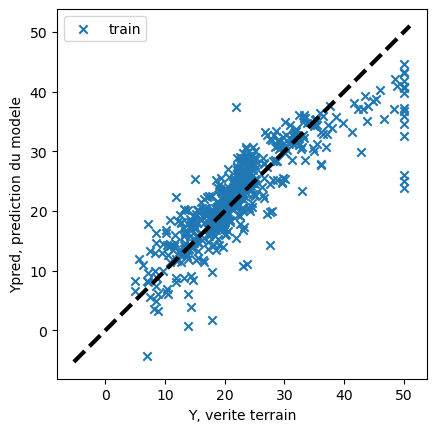

In [34]:
fig = plt.figure(1)
ax = fig.add_subplot(111)
plt.scatter(Y, Y_train_pred, marker='x', label='train')
plt.plot([xmin,xmax], [xmin,xmax], lw=3, color='k', ls='--') ## droite separatrice d'equation x2=x1

# ?labe -> xlabel ou ylabel: a vous de voir
plt.xlabel('Y, verite terrain')
plt.ylabel('Ypred, prediction du modele') 
plt.legend()
ax.set_aspect('equal') # on veut une figure carrée et pas allongée.
# plt.xlim([xmin,xmax])
# plt.ylim([xmin,xmax])

# Statisiques descriptives

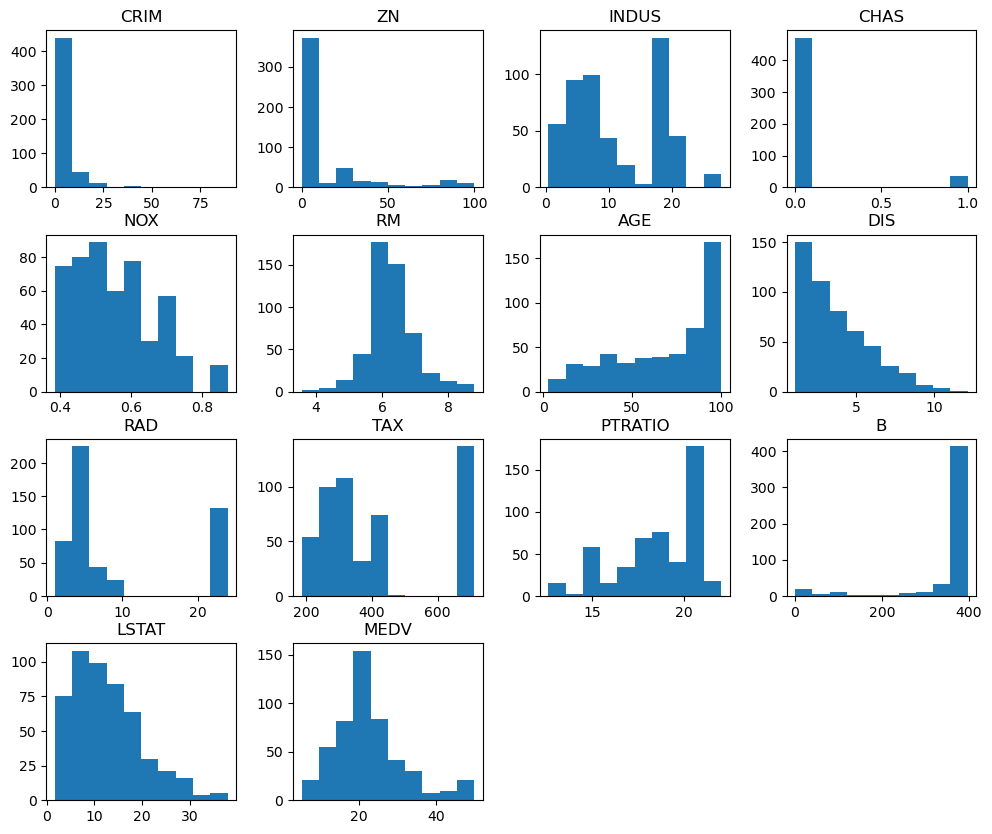

In [35]:
# Data visualizations

# histograms
dataset.hist(bins=10,figsize=(12,10),grid=False);

In [36]:
# on calcule les corréaltions entre colonnes (coeff. de correlation de Pearson)
# pd.set_option('precision', 2)
corre = dataset.corr(method='pearson')
corre

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


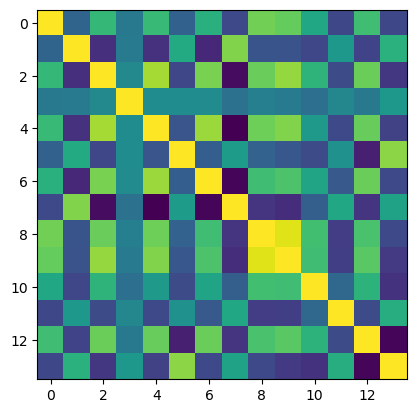

In [37]:
plt.imshow(corre)

## Addendum: on applique les bonnes pratiques, contrairement au premier jet ci-dessus

### C.a.d.: on partage le jeu de données entre train (donnée d'entrainement) et test (données pour évaluer la performance)

In [38]:
X_train, X_test, y_train, y_test = \
sklearn.model_selection.train_test_split(X,Y)

In [39]:
monModele.fit(X_train, y_train)

LinearRegression()

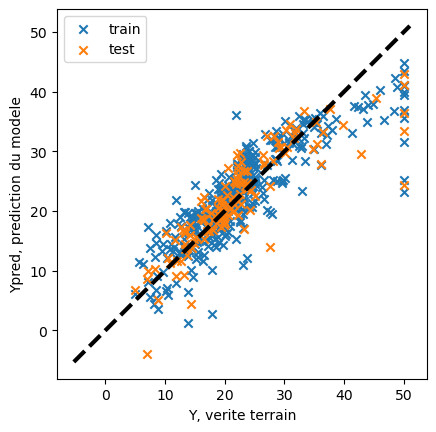

In [40]:
fig = plt.figure(1)
ax = fig.add_subplot(111)
plt.scatter(y_train, monModele.predict(X_train), marker='x', label='train')
plt.scatter(y_test, monModele.predict(X_test), marker='x', label='test')
plt.plot([xmin,xmax], [xmin,xmax], lw=3, color='k', ls='--') ## droite separatrice d'equation x2=x1

# ?labe -> xlabel ou ylabel: a vous de voir
plt.xlabel('Y, verite terrain')
plt.ylabel('Ypred, prediction du modele') 
plt.legend()
ax.set_aspect('equal') # on veut une figure carrée et pas allongée.
# plt.xlim([xmin,xmax])
# plt.ylim([xmin,xmax])

In [41]:
X_train.shape, X_test.shape

((379, 13), (127, 13))

In [42]:
monModele.score(X_train, y_train), monModele.score(X_test, y_test)

(0.7377958896051503, 0.7412298920344569)

In [43]:
?monModele.score